 Data Science и программировании рекурсия — очень важный и полезный инструмент при разработке алгоритмов. Вы можете столкнуться с рекурсией, например, в таких случаях:

В алгоритме дерева решений — одном из главных алгоритмов машинного обучения, который мы будем изучать в курсе.
В различных методах сортировки: сортировка вставками (Merge Sort), быстрая сортировка (Quick Sort).
В методах динамического программирования, которое используется в обучении с подкреплением.
Генерация изображений в видеоиграх.

СУММА ЭЛЕМЕНТОВ СПИСКА ЧЕРЕЗ РЕКУРСИЮ

Для начала рассмотрим простой, но важный для понимания пример. Вернёмся к задаче, которую уже решали множество раз различными способами, — поиску суммы элементов в списке.  На этот раз решим её с помощью рекурсии, чтобы понять, как она работает.

У нас есть список чисел, например [10, 21, 24, 12]. Нам необходимо посчитать сумму его элементов. Представим, что разучились складывать несколько чисел сразу, но помним, как складывать два числа между собой.

У нас есть четыре числа.

Что такое сумма чисел в списке [10, 21, 24, 12]? Это 10 + сумма в списке [21, 24, 12].

Что такое сумма списка [21, 24, 12]?  Это 21 + сумма [24, 12].

А что такое сумма списка [24, 12]? Это 24 + 12 = 36.

Элементов в списке больше не осталось.

А теперь идём в обратную сторону: 36 + 21 = 57; 57 + 10 = 67.

Математически наши вычисления можно представить следующим образом:


Не напоминают ли эти вычисления пример с зеркалом? Мы несколько раз подряд производили одну и ту же операцию — складывали первое число со списком из оставшихся. Но, в отличие от зеркала, когда мы дошли точки остановки — список закончился — мы прекратили выполнение операций и пошли в обратную сторону.

Это и есть пример рекурсивных вычислений: операция (функция) обращается к самой себе до тех пор, пока не выполнится условие. Теперь посмотрим, как это реализуется в коде.

Объявим функцию sum_lst() с одним аргументом lst — списком, по которому нужно рассчитать сумму.

Прежде всего в рекурсивной функции прописывается условие остановки — условие, когда функция возвращает определённое значение и осуществляется выход из рекурсии. Более детально о важности условия остановки мы поговорим чуть позже.

В нашем примере условие — список пуст (его длина равна 0). Если это условие выполнилось, мы возвращаем 0 (сумма пустого списка). В противном случае функция sum_lst() возвращает сумму первого элемента в списке с результатом вызова самой себя, но в аргументы уже передаётся список, из которого исключён первый элемент:

In [1]:
def sum_lst(lst):
    # Выводим текущее значение lst
    print(lst)
    # Задаём условие выхода из рекурсии
    if len(lst) == 0:
        return 0
    # Во всех других случаях возвращаем
    # сумму первого элемента списка 
    # и результат суммирования оставшихся
    return lst[0] + sum_lst(lst[1:])


my_lst = [10, 21, 24, 12]
print(sum_lst(my_lst))

[10, 21, 24, 12]
[21, 24, 12]
[24, 12]
[12]
[]
67


Примечание. Возможно, вы заметили, что задачу можно было бы решить без использования функции len(). Напомним, что благодаря неявному приведению типов (которое мы разбирали в модуле PYTHON-3) проверка списка на пустоту в условном операторе может выглядеть так: if not lst. Тогда рекурсивная функция sum_list() будет выглядеть следующим образом:

In [3]:
def sum_lst(lst):
    # Выводим текущее значение lst
    print(lst)
    # Задаем условие выхода из рекурсии
    if not lst:
        return 0
    # Во всех других случаях возвращаем
    # сумму первого элемента списка 
    # и результат суммирования оставшихся
    return lst[0] + sum_lst(lst[1:])

my_lst = [10, 21, 24, 12]
print(sum_lst(my_lst))

[10, 21, 24, 12]
[21, 24, 12]
[24, 12]
[12]
[]
67


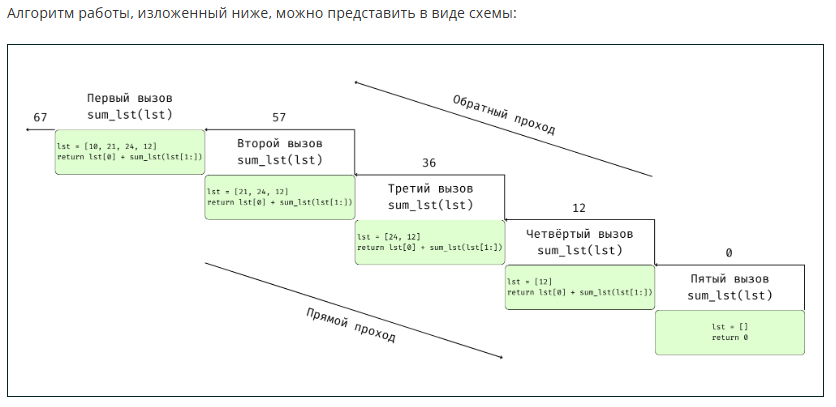

### СТЕК ВЫЗОВА ФУНКЦИЙ

Такая структура данных, в которой первым обрабатывается элемент (в данном случае задача), появившийся последним, называется стеком (или «стопкой»). Мы получили стек задач. Более формально он и называется стеком вызовов функции (call stack). В стеке действует правило LIFO (Last In, First Out) — «последний вошёл — первый вышел».

** Напишите рекурсивную функцию multiply_lst(lst), которая перемножает элементы заданного списка lst между собой. Если в функцию передаётся пустой список, она должна возвращать 1.

In [6]:
def multiply_lst(lst):
    print(lst)
    if not lst:
        return 1
    return lst[0] * multiply_lst(lst[1:])
    
lst = [3, 5, 7, 12, 14, 15, 5]
multiply_lst(lst)

[3, 5, 7, 12, 14, 15, 5]
[5, 7, 12, 14, 15, 5]
[7, 12, 14, 15, 5]
[12, 14, 15, 5]
[14, 15, 5]
[15, 5]
[5]
[]


1323000

Напишите рекурсивную функцию inv_sum_list(). На вход ей подаётся список из чисел, а она вычисляет сумму чисел, являющихся обратными к своим элементам. Обратным числу x называется число 1/x. Например, обратным числу 2 является 1/2 = 0.5.

Например, если на вход программы подается список [10, 4, 8], то функция должна вернуть сумму 0.1 + 0.25 + 0.125 = 0.475.

Если на вход функции передаётся пустой список, она должна возвращать 0.

In [12]:
def inv_sum_list(lst):
    if not lst:
        return 0
    sum_list = []
    for elem in lst:
        sum_list.append(1/elem)
    return sum_list[0] + inv_sum_list(sum_list[1:])
lst = [1, 2 ,5, 10]
inv_sum_list(lst)

13.2

### Факториал через рекурсию

Факториал можно записать с помощью рекурсивной функции: будем умножать n на (n-1)! до тех пор, пока под факториалом не окажется 0 или 1, для которых нам известно точное значение факториала.

Создадим рекурсивную функцию factorial для вычисления факториала. Её аргументом будет целое число n. Функция будет рекурсивной, а условий остановки в ней будет сразу два: если n == 0 или n == 1 (в таком случае функция возвращает 1, об этом мы говорили ранее). Если условия остановки не выполняются, то функция возвращает результат умножения числа n на результат своей же работы для числа n-1: n * (n-1)!.

In [13]:
def factorial(n):
    # Задаём условия выхода из рекурсии:
    if n==0: return 1
    if n==1: return 1
    # Во всех других случаях возвращаем
    # произведение текущего числа n и функции от n-1
    return factorial(n-1) * n

In [14]:
print(factorial(0))
print(factorial(3))
print(factorial(5))

1
6
120


** Напишем функцию combination(n, k), которая позволит нам автоматически вычислять значение сочетания по формуле, приведённой выше, для любых n и k.

При расчёте воспользуйтесь рекурсивной функцией factorial(), которую мы написали выше. Можете сделать её внутренней для функции combination() или независимой функцией, на ваш вкус. Главное, добавьте в свой код объявление функции factorial().

In [15]:
def combination(n, k):
    def factorial(n):
    # Задаём условия выхода из рекурсии:
        if n==0: return 1
        if n==1: return 1
    # Во всех других случаях возвращаем
    # произведение текущего числа n и функции от n-1
        return factorial(n-1) * n
    c = factorial(n) / (factorial(n-k) * factorial(k))
    return c
print(combination(n=10, k=5))

252.0


### Глубина рекурсии

Теперь поближе посмотрим на условия остановки, на две очень важные строки в коде нашей функции:

In [16]:
def factorial(n):
    # Задаём условия выхода из рекурсии:
    if n==0: return 1
    if n==1: return 1
    # Во всех других случаях возвращаем
    # произведение текущего числа n и функции от n-1
    return n * factorial(n-1)

Они задают условие, при выполнении которого функция возвращает конкретное значение, а не продолжает ссылаться на саму себя. 

Давайте удалим условие выхода:

In [17]:
def wrong_factorial(n):
    # Удалили условие остановки
    return wrong_factorial(n-1) * n
## Вызываем функцию
wrong_factorial(5)

RecursionError: maximum recursion depth exceeded

KeyboardInterrupt: 

Эта ошибка переводится так: «Ошибка рекурсии: превышена максимальная глубина рекурсии». Это своего рода встроенная защита от бесконечной рекурсии в Python.

Мы знаем, что с рекурсией происходит наполнение стека вызовов новыми вызовами рекурсивной функции. Очень тесно с этим явлением связан термин ** глубина рекурсии **

Число единовременно ожидающих выполнения вызовов рекурсивной функции в стеке и называется глубиной рекурсии. Проще говоря, глубина рекурсии — это длина стека вызова. 

На самом деле ошибка RecursionError может возникнуть не только для рекурсивной функции, для которой забыли написать условие выхода. К сожалению, интерпретатор не может понять, есть ли условие выхода в коде функции, поэтому, когда в его стеке собирается слишком много вызовов той же самой функции, он возвращает ошибку. Это защита от бесконечного выполнения программы. Этот порог индивидуален и может зависеть от сложности самой функции, версии Python и других настроек. 

In [18]:
# Числа стали слишком большими, чтобы их печатать
# Будем печатать число цифр в результате
print(len(str(factorial(969))))

2475


In [19]:
print(len(str(factorial(970))))

2478


In [21]:
print(len(str(factorial(1000))))

2568


Увеличим максимально допустимую глубину рекурсии, например до 1 000 000 000. Для этого нам необходимо импортировать модуль sys, в котором содержатся функции для управления системой. Из него нам понадобится функция setrecursionlimit(), в аргументы которой нужно передать желаемую максимальную глубину рекурсии.

После небольшой донастройки снова попробуем посчитать факториал от 970.

In [24]:
# Импортируем модуль для работы с системными переменными
import sys
# Увеличим глубину рекурсии
sys.setrecursionlimit(1000000000)
print(len(str(factorial(1500))))

4115


Вы научились создавать рекурсивные функции с условием выхода из рекурсии. В Data Science вы обязательно столкнётесь с ситуациями, когда применение рекурсии покажется вам наиболее простым методом для решения задачи. Тот же перебор вложенных папок, в которых у вас могут находиться файлы, создание последовательностей чисел (скажем, числа Фибоначчи, применяемые, например, для определения отрезков времени, через которые произойдёт то или иное событие) или генерация распределений.

К тому же, рекурсии лежат в основе множества алгоритмов, в том числе алгоритмов машинного обучения.

Важно учитывать, что рекурсии работают медленнее, чем аналогичные по сути циклы. К тому же существует ряд случаев, когда преобразование рекурсии в цикл затруднительно и неэффективно, например реализация алгоритма дерева решений, быстрое преобразование Фурье или алгоритм quicksort. Однако когда это оказывается возможным, цикл работает быстрее.

** Числа Фибоначчи — пример последовательности, которую можно получить рекурсивно. Каждое число из последовательности является суммой двух предыдущих.

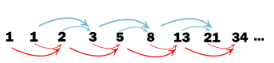

Напишите рекурсивную функцию fib(n), которая считает n-ое число Фибоначчи. Алгоритм работы функции:

Если n=1 или n=2, вернуть 1, так как первый и второй элементы ряда Фибоначчи равны единице.
Во всех остальных случаях вызвать эту же функцию с аргументами n-1 и n-2 и сложить результаты двух вызовов.

In [25]:
def fib(n):
    if n == 1 or n == 2:
        return 1
    else:
        return fib(n-1) + fib(n-2)
   

In [26]:
print(fib(1))
# 1
print(fib(2))
# 1
print(fib(6))
# 8


1
1
8


** Напишите рекурсивную функцию power(val, n), которая возводит число в заданную целую натуральную степень (или в степень 0).

Использовать встроенный оператор ** для возведения в степень запрещено. Пользуйтесь только умножением *. Например, 2 ** 4 = (((2 * 2) * 2) * 2) = 16.

В качестве первого аргумента функция принимает число, в качестве второго — желаемую степень.

Примечание. В качестве базовых случаев для рекурсии возьмите условия, что любое число в степени 0 — 1, любое число в степени 1 — это же число.

In [27]:
def power(val, n):
    if n ==0:
        return 1
    elif n ==1:
        return val
    else:
        result = val * power (val, n-1)
    return result
print(power(25, 0))

print(power(-5, 4))

1
625


** РАССТАВИТЬ СКОБКИ

Задача №1

Условие задачи

Необходимо написать функцию add_brackets(), которая принимает на вход строку, содержащую только английские буквы (большие и маленькие). Функция должна добавлять в строку открывающиеся и закрывающиеся скобки по следующему образцу: "example" → "e(x(a(m)p)l)e".

До середины добавляются открывающие скобки, после середины – закрывающие. Если длина строки равна чётному числу, в скобках, расположенных в середине, должно быть два символа: "card" → "c(ar)d" (но не "c(a()r)d").

Решение

Задача очень просто решается через рекурсию. Мы должны «отщипывать» от строки первый и последний символы, добавляя к ним справа и слева символы открывающей и закрывающей скобок, а посередине добавлять результат вызова функции для строки, из которой исключены символы начала и конца исходной. Функция будет продолжать свою работу до тех пор, пока длина строки не станет равной одному или двум.

In [28]:
# Функция для создания строки со скобками
def add_brackets(s):
    # Проверяем условие остановки: строка состоит из одного или двух символов
    if len(s) == 1 or len(s) == 2:
        # Возвращаем эти символы
        return s
    # В противном случае:
    # «Отщипываем» от строки первый и последний символы,
    # добавляем к ним скобки, а также результат вызова функции, в которую
    # передаем строку без первого и последнего символов
    return s[0] + '(' + add_brackets(s[1:-1]) + ')' + s[-1]

In [29]:
print(add_brackets('example'))
print(add_brackets('carr'))
print(add_brackets('hello'))

e(x(a(m)p)l)e
c(ar)r
h(e(l)l)o


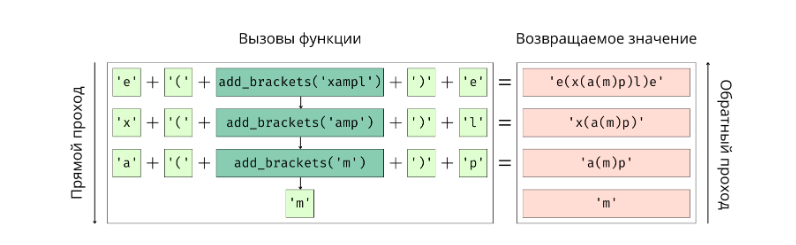

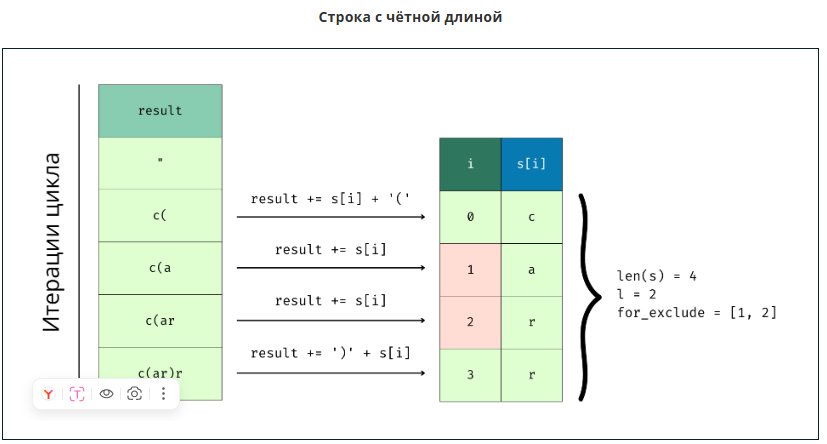

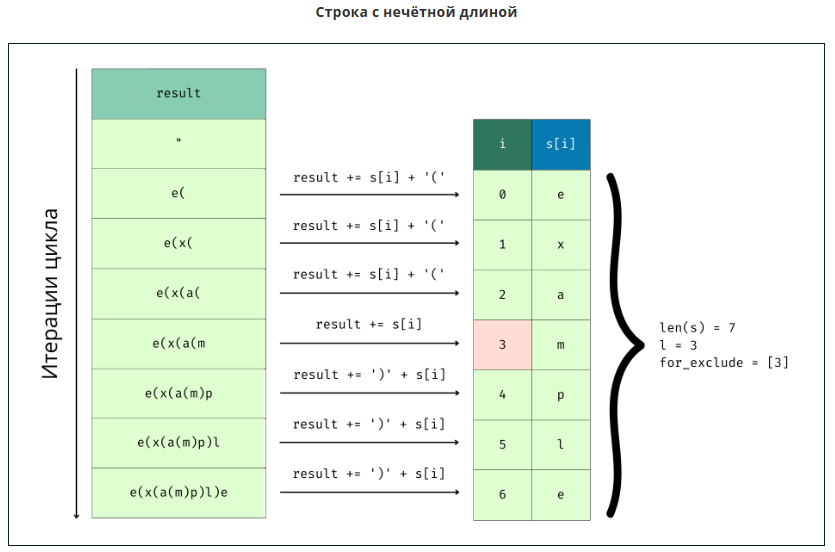

** Дана строка, содержащая только английские буквы (большие и маленькие).

Напишите рекурсивную функцию add_asterisk(). Она должна принимать в качестве аргумента строку и добавлять символ * (звёздочка) между буквами. Перед первой и после последней буквами символ * добавлять не нужно

In [30]:
def add_asterisk(s):
    if len(s)<=1:
        return s
    s = s[0]+'*'+ add_asterisk(s[1:])
    return s
print(add_asterisk('mama'))
## h*e*l*l*o
print(add_asterisk('LItBeoFLcSGBOFQxMHoIuDDWcqcVgkcRoAeocXO'))

m*a*m*a
L*I*t*B*e*o*F*L*c*S*G*B*O*F*Q*x*M*H*o*I*u*D*D*W*c*q*c*V*g*k*c*R*o*A*e*o*c*X*O


** РАБОТА СО ВЛОЖЕННЫМИ СПИСКАМИ

Задача №2

Условие задачи

В машинном обучении мы часто работаем с многомерными структурами, например двумерными матрицами.

Пример матрицы размером 3x3 (3 строки, 3 столбца):

In [31]:
matrix = [
    [1, 1, 0],
    [4, 2, 1],
    [0, 2, 1]
]

Могут быть и гораздо более сложные структуры, например трёхмерные или четырёхмерные массивы, но пока остановимся на двумерных.

В глубоком обучении (Deep Learning) есть специальная операция под названием flatten. Эта операция является важной частью архитектуры свёрточных нейронных сетей: она выпрямляет любой многомерный массив в одномерный.

Например, в результате выполнения операции flatten для вложенного списка matrix мы должны получить список следующего вида:

In [ ]:
print(flatten(matrix))
## [1, 1, 0, 4, 2, 1, 0, 2, 1]

Напишем функцию flatten(), которая принимает на вход список, состоящий из других списков, и возвращает обычный список, в котором присутствуют все элементы из вложенных списков.

Решение

Однотипные вложенные структуры данных, вложенность которых заранее может быть неизвестна, — это прямой намёк на рекурсию.

Создадим функцию flatten(), которая будет принимать в качестве параметра вложенный список lst. В теле функции будем при каждом её вызове создавать новый пустой список result.

В цикле будем проходиться по элементам списка lst.

Если текущий элемент списка lst сам по себе является списком, будем снова применять к нему функцию для выпрямления flatten(), а результат, который получится после вызова этой функции, конкатенировать (объединять) с уже имеющимся списком result.
В противном случае будем просто добавлять элемент в список result.
Функция будет возвращать результирующий новый список result.

Итоговый код будет выглядеть следующим образом:

In [34]:
# Функция для выпрямления списка
def flatten(lst):
    # Создаём новый пустой список
    result = []
    # Создаём цикл по элементам списка
    for elem in lst:
        # Если элемент списка является списком,
        if type(elem) is list:
            # Применяем к нему функцию выпрямления и добавляем элементы к результату
            result += flatten(elem)
        else: # Если элемент не является списоком,
            # Добавляем элемент в новый список
            result.append(elem)
    return result

In [35]:
matrix = [
    [1, 1, 0],
    [4, 2, 1],
    [0, 2, 1]
]
print(flatten(matrix))

[1, 1, 0, 4, 2, 1, 0, 2, 1]


Обратите внимание: главное преимущество рекурсивной функции — это то, что она работает независимо от количества вложенности нашего списка.

Рассмотрим пример:

In [36]:
matrix = [
    [1, 1, [5, 10, 34, [24, 1, 0]]],
    [4, [9, 8, 10], 1],
    [0, 2, 1]
]
print(flatten(matrix))

[1, 1, 5, 10, 34, 24, 1, 0, 4, 9, 8, 10, 1, 0, 2, 1]


** Другая важная операция в нейронных сетях — это суммирование элементов исходной матрицы.

Напишите функцию sum_list(). Она принимает на вход вложенный список, элементами которого являются числа, и возвращает сумму всех элементов.

In [37]:
matrix = [
    [1, 1, 0],
    [4, 2, 1],
    [0, 2, 1]
]
def sum_list(lst):
    def flatten(lst):
        result = []
        for elem in lst:
            if type(elem) is list:
                result += flatten(elem)
            else:
                result.append(elem)
        return result
    s = sum(flatten(lst))
    return s
print(sum_list(matrix))

12


** ДРЕВОВИДНЫЕ СТРУКТУРЫ

Задача №3

Условие задачи

Мы администрируем некоторый форум. Каждое сообщение на форуме имеет свой идентификатор. Сообщения на форуме могут иметь древовидную структуру, то есть существует корневое сообщение (нулевой уровень), на это сообщение могут быть ответы (первый уровень), а на каждый из этих ответов могут быть ещё ответы (второй уровень). Такая структура может быть бесконечной. То есть каждое сообщение может иметь:

родителя — сообщение, на которое мы ответили на форуме своим сообщением;
потомков — сообщения, которые являются ответом на наше сообщение.
Дан словарь forum_messages, ключами которого являются идентификаторы (id) сообщений на форуме. Значения в свою очередь также являются словарями. У этих словарей есть два ключа:

parrent_link — родительская ссылка: может быть целым числом, если сообщение является ответом на другое сообщение, или None, если сообщение является корневым на форуме;
child_link — список из идентификаторов дочерних сообщений, если таковые имеются, и пустой список, если таковых нет.

In [38]:
forum_messages = {
    1: {'parrent_link': None, 'child_link': [3, 4]},
    2: {'parrent_link': None, 'child_link': [5]},
    3: {'parrent_link': 1, 'child_link': [6]},
    4: {'parrent_link': 1, 'child_link': []},
    5: {'parrent_link': 2, 'child_link': []},
    6: {'parrent_link': 3, 'child_link': []}
}

Схема (такая схема в математике называется графом), которая изображает сообщения, представленные в словаре >forum_messages, представлена ниже:

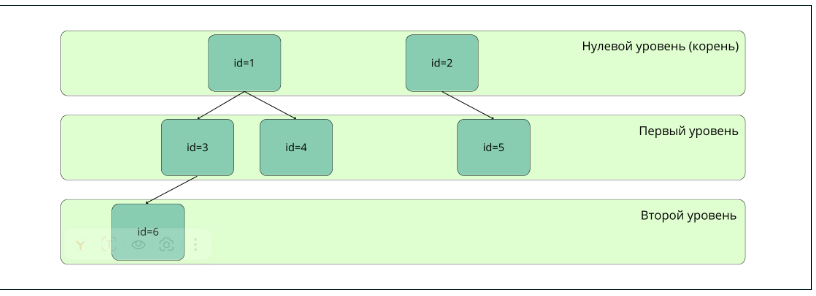

Необходимо реализовать функцию delete_message(), которая принимает на вход словарь со структурой форума и идентификатор сообщения. Функция должна удалять идентификатор сообщения из словаря, а также идентификаторы дочерних сообщений.

Например, вызов функции delete_message(forum_messages, msg_id=3) должен вернуть следующий словарь:

In [ ]:
{1: {'parrent_link': None, 'child_link': [4]},
    2: {'parrent_link': None, 'child_link': [5]},
    4: {'parrent_link': 1, 'child_link': []},
    5: {'parrent_link': 2, 'child_link': []}}

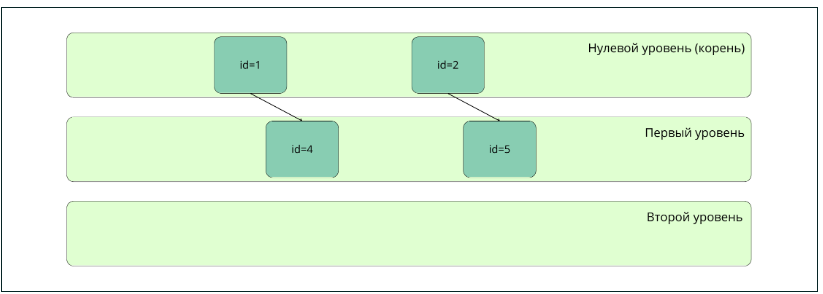

Решение

Разберёмся с этой сложной, на первый взгляд, задачей.

Для начала поймём, какие действия должны быть выполнены, когда мы удаляем сообщение:

Удалить само сообщение, то есть удалить из словаря ключ msg_id и значение, соответствующее ему.
Если у сообщения есть родитель (идентификатор родителя лежит по ключу 'parrent_link') и этот родитель ещё не был удалён на предыдущих этапах, то нужно удалить идентификатор удаляемого сообщения из списка потомков (в родительском сообщении он лежит по ключу 'child_link').
Если у сообщения есть потомки, то нужно в цикле пройтись по каждому из потомков и повторить действия из пунктов 1–3.
В результате нужно вернуть обновлённый словарь messages.
Итоговый код будет выглядеть следующим образом:

In [39]:
# Функция для удаления сообщения на форуме и всех его потомков
def delete_message(messages, msg_id):
    # Удаляем из словаря сообщение с идентификатором msg_id
    # Метод pop() возвращает значение, лежащее по удаляемому ключу
    result = messages.pop(msg_id)
    # Получаем идентификатор родителя
    parrent_link = result['parrent_link']
    # Получаем список идентификаторов потомков
    child_link = result['child_link']
    # Если у сообщения был родитель и он ещё не был удален
    # Эта запись будет аналогична parrent_link is not None
    if parrent_link and parrent_link in messages:
        # Обращаемся к словарю messages по ключу родителя
        # Удаляем потомка из списка потомков
        messages[parrent_link]['child_link'].remove(msg_id)
    # Если у сообщения были потомки
    # Эта запись будет аналогична child_link == [<значение_1>, <значение_2>, ...]
    if child_link:
        # В цикле проходимся по всем потомкам 
        for child_id in child_link:
            # И повторяем те же самые действия для каждого из них
            # (рекурсивно вызываем функцию delete_message)
            delete_message(messages, msg_id=child_id)
    return messages

In [40]:
print(delete_message(forum_messages, msg_id=5))

{1: {'parrent_link': None, 'child_link': [3, 4]}, 2: {'parrent_link': None, 'child_link': []}, 3: {'parrent_link': 1, 'child_link': [6]}, 4: {'parrent_link': 1, 'child_link': []}, 6: {'parrent_link': 3, 'child_link': []}}


In [41]:
print(delete_message(forum_messages, msg_id=3))

{1: {'parrent_link': None, 'child_link': [4]}, 2: {'parrent_link': None, 'child_link': []}, 4: {'parrent_link': 1, 'child_link': []}}


Обратите внимание: так как функция delete_message() изменяет сам словарь forum_messages, то для того чтобы получить такие же результаты, как представлены выше, необходимо перезапускать программу, заново инициализируя словарь forum_messages после каждого удаления.